In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'SeoulBikeData.csv',encoding = "latin1")

In [3]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [5]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [6]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

<Axes: xlabel='Hour'>

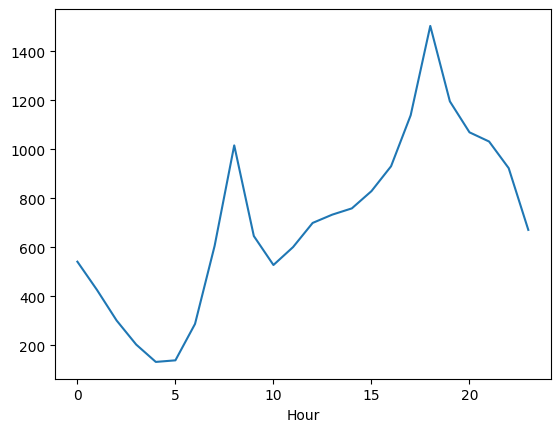

In [7]:
df.groupby("Hour")['Rented Bike Count'].mean().plot()

***This graph shows the average number of rented bikes for each hour of the day.***

***Morning peak***(6-9 AM): Students and office commuters travelling to their destinations.

***Evening peak***(3-7 PM): People returning back from their work stations. 

***Very low rentals at late night***(0–5 AM): Expected due to low activity during these hours.

Steady rise after early morning hours and a drop after evening indicates typical urban commuting behavior.

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

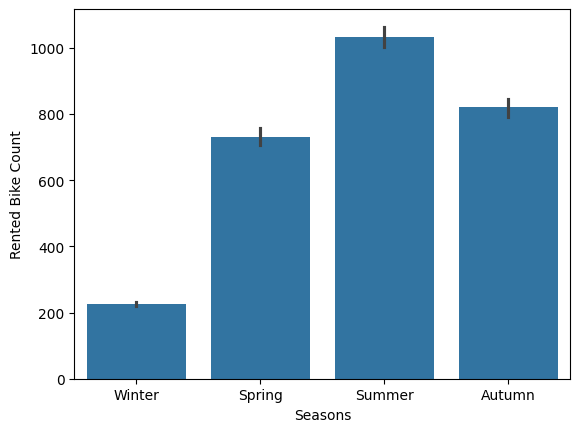

In [8]:
sns.barplot(data=df, x='Seasons', y='Rented Bike Count')

***This graph shows the average number of rented bikes across the four seasons.***

Summer has the highest rentals: Warm temperatures and longer daylight hours encourage more outdoor mobility and recreational riding.

Autumn shows moderate rentals: Comfortable weather makes cycling convenient, but rentals begin to decline as temperatures drop.

Spring also records healthy bike usage: Increasing temperatures and pleasant climate contribute to rising rental numbers.

Winter has the lowest rentals: Cold temperatures, snowfall, and icy conditions significantly reduce bike usage.

<Axes: xlabel='Temperature(°C)', ylabel='Rented Bike Count'>

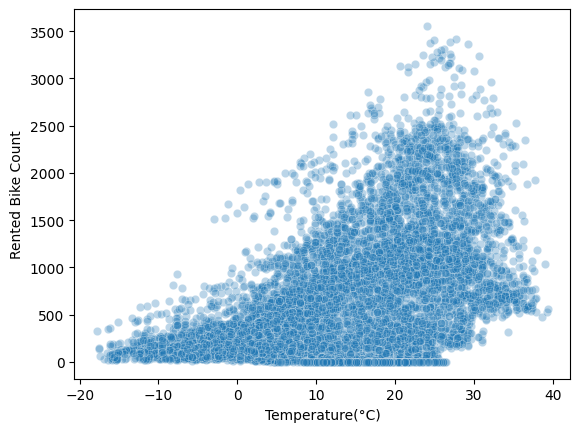

In [9]:
sns.scatterplot(data=df, x="Temperature(°C)", y="Rented Bike Count", alpha=0.3)

***This scatter plot shows how temperature influences the number of rented bikes.***

***Higher temperatures lead to higher rentals***: Warm and pleasant weather encourages more people to ride bikes for commute and leisure.

***Very low rentals at low temperatures***: During cold days, people avoid cycling due to discomfort, snow, or icy conditions.

***Clear upward spread***: As the temperature rises, the spread of points becomes denser in the higher rental range, showing strong positive influence of temperature on bike demand.

In [10]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df.Date.dt.month_name().str[:3]
df['Year'] = df.Date.dt.year
df['Weekday']=df.Date.dt.weekday

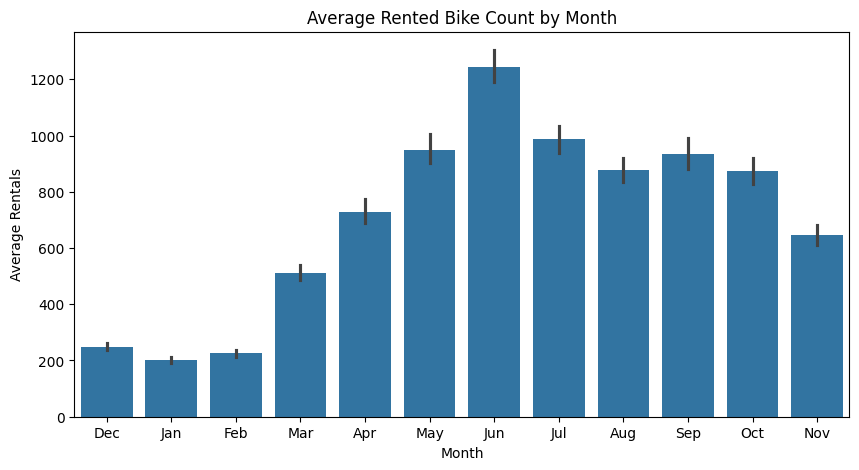

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Month", y="Rented Bike Count", estimator="mean")
plt.title("Average Rented Bike Count by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.show()

***This graph shows how the average number of rented bikes changes across different months of the year.***

***Summer months record the highest rentals***: Warm temperature and longer daylight hours encourage more outdoor mobility and bike commuting.

***Spring and Autumn show moderate usage***: Pleasant climate conditions support regular rentals, though not as high as summer.

***Winter has the lowest rentals***: Cold weather, snow, and icy conditions reduce the willingness to cycle.

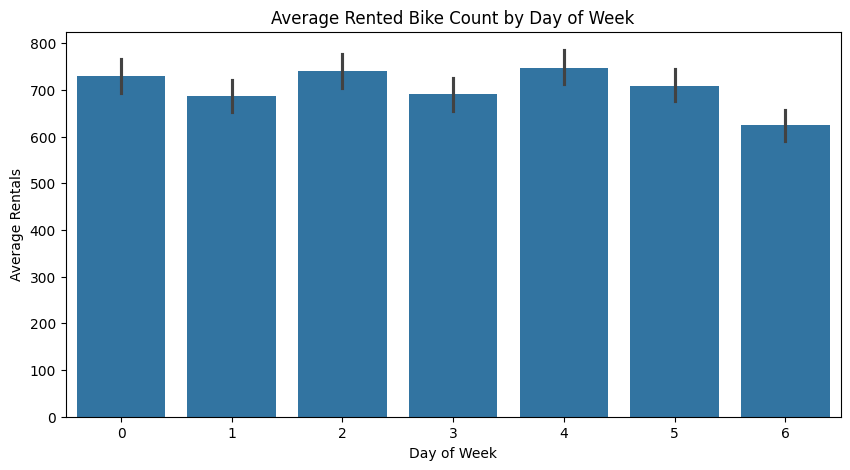

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Weekday", y="Rented Bike Count", estimator="mean")
plt.title("Average Rented Bike Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Rentals")
plt.show()


***This graph shows the average number of rented bikes for each day of the week.***

***Weekdays (Monday–Friday) show higher rentals***: This is due to office commuters and students traveling regularly on working days.

***Saturday shows moderate usage***: People tend to use bikes for leisure activities and short-distance outings.

***Sunday has the lowest rentals***: Reduced commute activity results in lower demand for bikes.

**Sales Improvement Tip**: Introduce longer periods of time as offer on the same fare during weekends

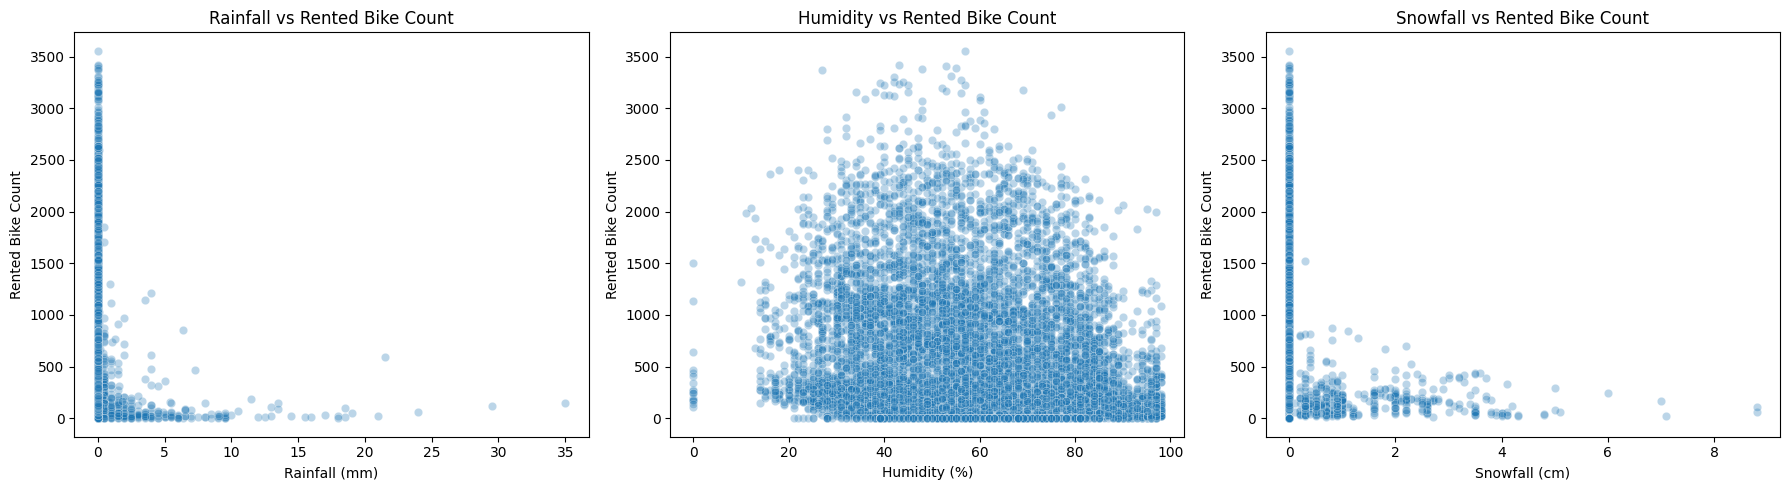

In [13]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.scatterplot(data=df, x="Rainfall(mm)", y="Rented Bike Count", alpha=0.3)
plt.title("Rainfall vs Rented Bike Count")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Rented Bike Count")

plt.subplot(1,3,2)
sns.scatterplot(data=df, x="Humidity(%)", y="Rented Bike Count", alpha=0.3)
plt.title("Humidity vs Rented Bike Count")
plt.xlabel("Humidity (%)")
plt.ylabel("Rented Bike Count")

plt.subplot(1,3,3)
sns.scatterplot(data=df, x="Snowfall (cm)", y="Rented Bike Count", alpha=0.3)
plt.title("Snowfall vs Rented Bike Count")
plt.xlabel("Snowfall (cm)")
plt.ylabel("Rented Bike Count")

plt.tight_layout()
plt.show()

**These graphs highlight how key weather conditions rainfall, humidity, and snowfall negatively impact the number of rented bikes.**

**Rainfall**: Even light rain sharply reduces rentals as wet roads make cycling unsafe.

**Humidity**: High humidity lowers rentals because riders feel discomfort and reduced visibility.

**Snowfall**: Snowfall causes rentals to drop to near-zero due to slippery and unsafe conditions.

**Sales Improvement Tip**: Introduce weather-based discounts or offers (e.g., light-rain cashback, cold-day discounts) to encourage ridership even under mild weather conditions

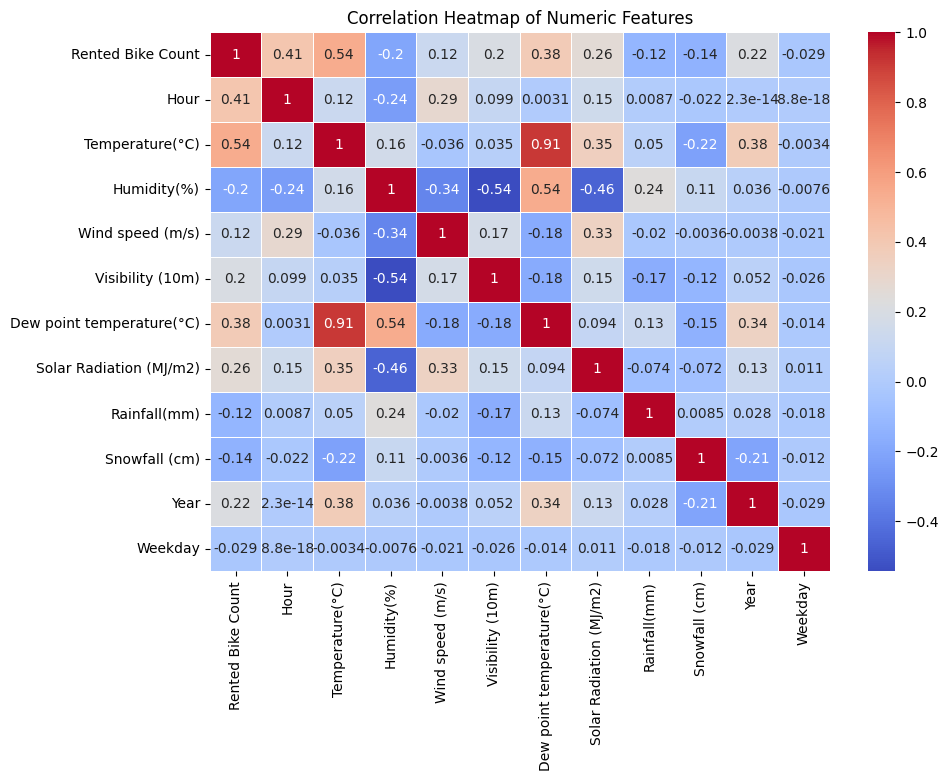

In [14]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**This heatmap visualizes the correlation between all numeric variables in the dataset, revealing how different weather and time-based features relate to bike rental demand.**

**Strong positive correlation with temperature**: Higher temperatures are associated with higher bike rental counts, showing that warmer weather encourages more cycling.

**Strong negative correlation with humidity and rainfall**: High humidity or rainy conditions reduce rider comfort, leading to fewer rentals.

**Hour shows a meaningful pattern**: Certain times of the day have more predictable riding activity, mainly during office commute hours.

**Snowfall and visibility have moderate effects**: Snow drastically lowers rentals, while lower visibility slightly reduces riders due to safety concerns.

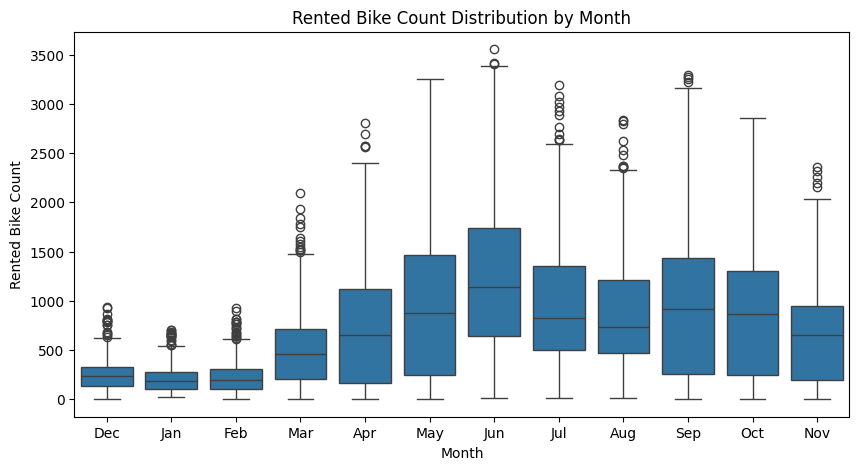

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Month", y="Rented Bike Count")
plt.title("Rented Bike Count Distribution by Month")
plt.show()

**This boxplot shows how the distribution of rented bikes varies across different months of the year.**

**Summer months show the highest rental variability**: Warm temperatures and longer days result in frequent and higher bike usage, with several peak days visible as upper whiskers and outliers.

**Winter months have the lowest and most consistent rentals**: Cold weather, icy roads, and reduced daylight cause a drop in usage, creating shorter boxes and fewer high-value outliers.

**Spring and Autumn show moderate rental patterns**: Pleasant weather during these months leads to a balanced spread of rentals without extreme highs or lows.

**Clear seasonal transitions**: The boxplot captures how rider demand gradually rises from winter to summer and declines afterward.

**Sales Improvement Tip**: Introduce seasonal subscription offers or discounts during low-demand winter months to encourage more consistent ridership and reduce seasonal dips in rentals.

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

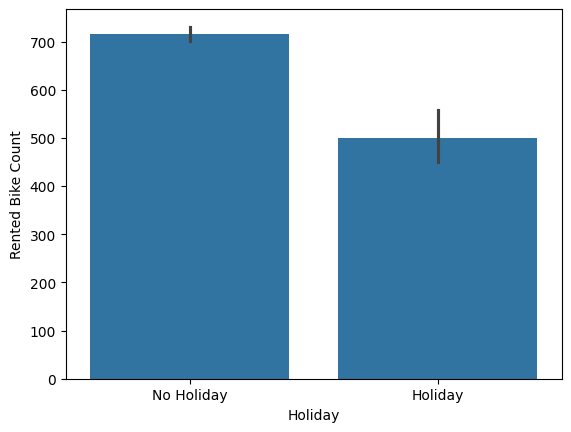

In [16]:
sns.barplot(data=df, x="Holiday", y="Rented Bike Count")

**This graph compares the average number of rented bikes on holidays versus non-holidays.**

**Non-holidays show significantly higher rentals**: Regular workdays drive strong commuting demand as students and office workers rely on bikes for daily travel.

**Holidays have noticeably lower rentals**: With fewer commuters, bike usage drops as people stay indoors or travel shorter distances.

**Clear usage gap**: The difference highlights how strongly bike rentals depend on weekday routines and work schedules.

**Sales Improvement Tip**: Introduce special holiday promotions such as family passes, tourist bundles, or half-day discounts to boost ridership when regular commuter usage drops.

Text(0.5, 1.0, 'Holiday Count Distribution')

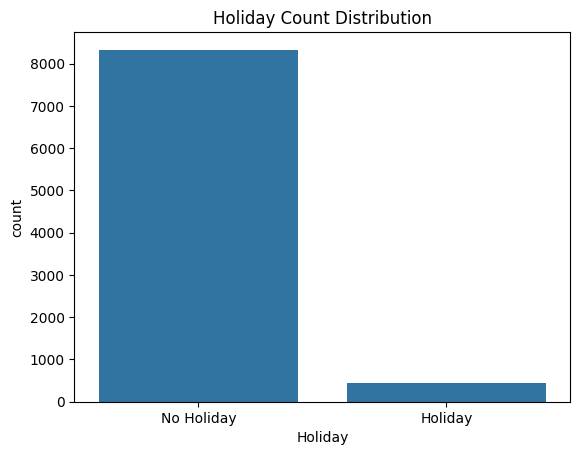

In [17]:
sns.countplot(data=df, x="Holiday")
plt.title("Holiday Count Distribution")

**This graph shows how many entries in the dataset correspond to holidays versus non-holidays.**

The large difference between holiday and non-holiday counts highlights that the bike rental system is primarily used during normal working days.

<Axes: xlabel='Functioning Day', ylabel='Rented Bike Count'>

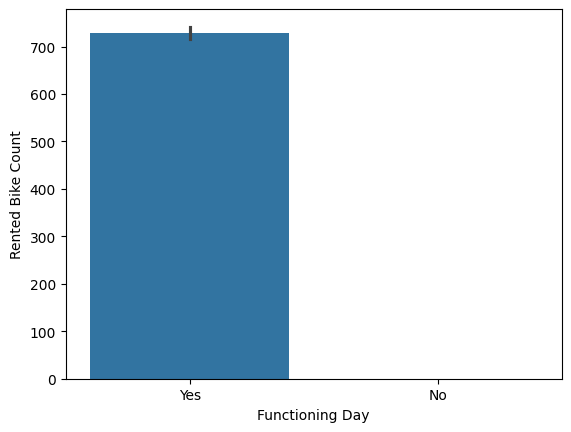

In [18]:
sns.barplot(data=df, x="Functioning Day", y="Rented Bike Count")

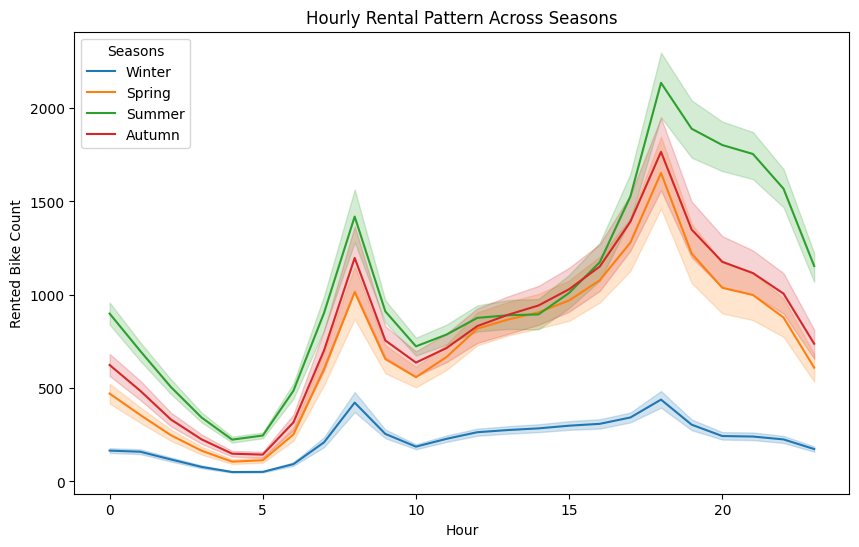

In [19]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Hour", y="Rented Bike Count", hue="Seasons")
plt.title("Hourly Rental Pattern Across Seasons")
plt.show()

**This graph compares how the number of rented bikes changes by hour across different seasons.**

Summer shows the highest hourly rentals. Winter shows the lowest rentals. Spring and Autumn display moderate and balanced hourly patterns.


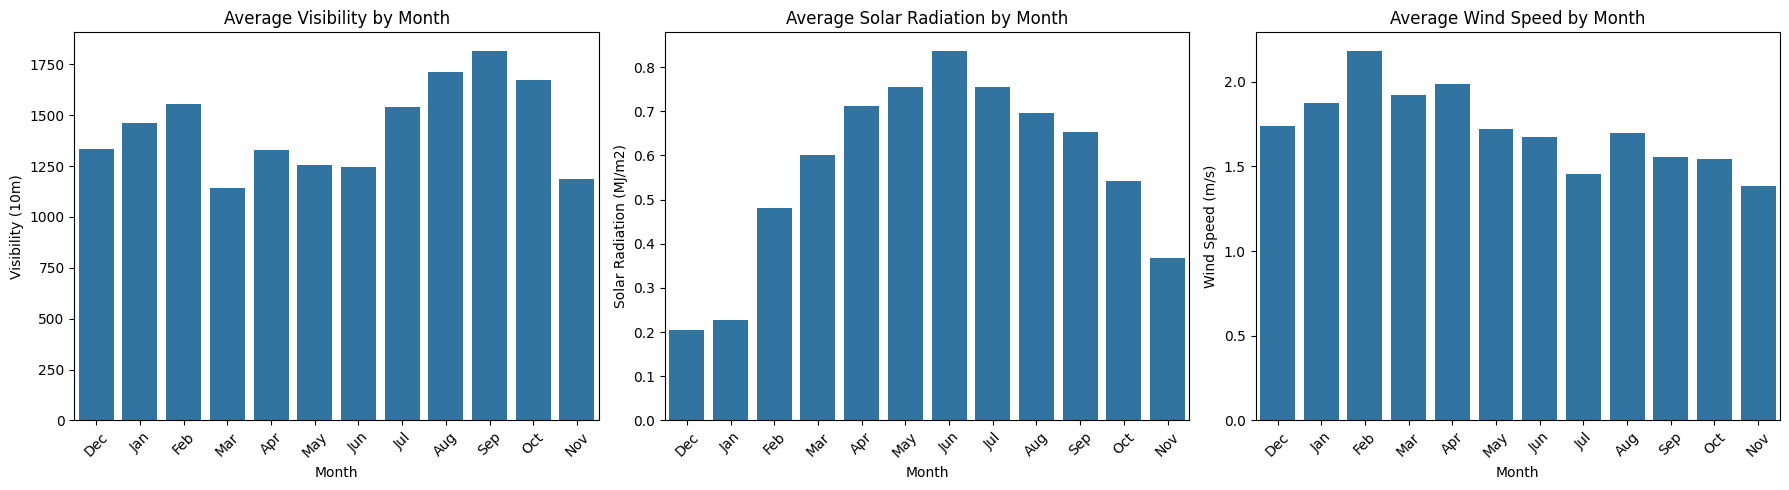

In [20]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.barplot(x=df["Month"],y=df["Visibility (10m)"],estimator='mean',errorbar=None)
plt.title("Average Visibility by Month")
plt.xlabel("Month")
plt.ylabel("Visibility (10m)")
plt.xticks(rotation=45)

plt.subplot(1,3,2)
sns.barplot(x=df["Month"],y=df["Solar Radiation (MJ/m2)"],estimator='mean', errorbar=None)
plt.title("Average Solar Radiation by Month")
plt.xlabel("Month")
plt.ylabel("Solar Radiation (MJ/m2)")
plt.xticks(rotation=45)

plt.subplot(1,3,3)
sns.barplot(x=df["Month"],y=df["Wind speed (m/s)"],estimator='mean',errorbar=None)
plt.title("Average Wind Speed by Month")
plt.xlabel("Month")
plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**These three barplots compare how key weather conditions visibility, solar radiation, and wind speed change across different months of the year.**

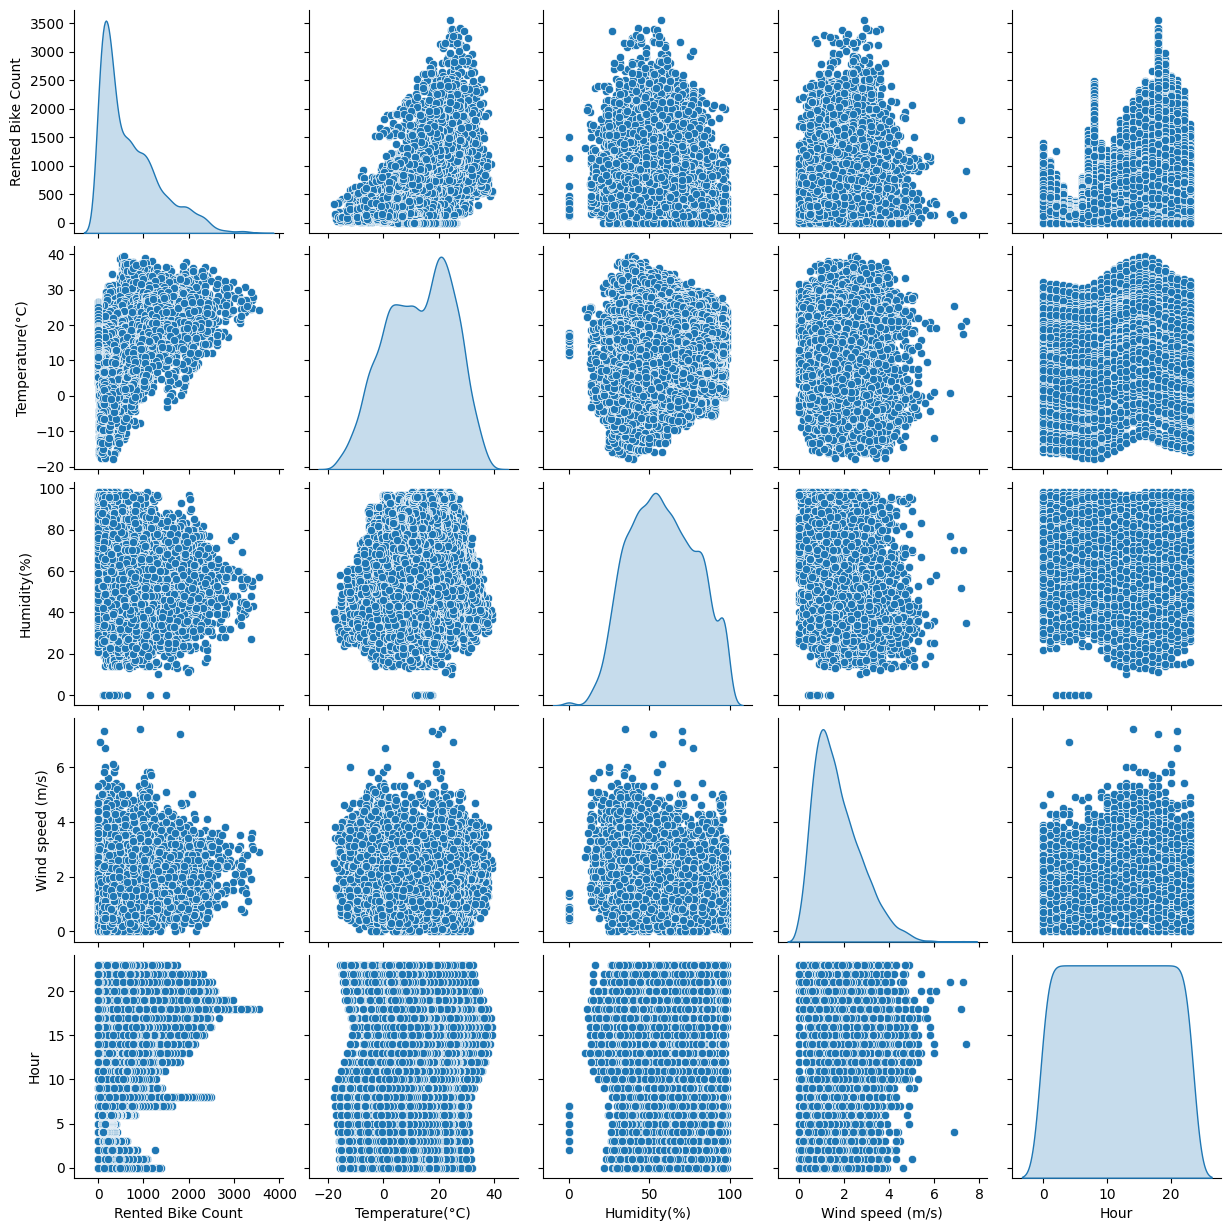

In [21]:
sns.pairplot(df[['Rented Bike Count','Temperature(°C)','Humidity(%)','Wind speed (m/s)','Hour']], diag_kind="kde")
plt.show()

**This pairplot visualizes the relationships between the most important variables affecting bike rentals, including temperature, humidity, wind speed, and hour of the day.**

These visual relationships confirm the trends identified in earlier plots and help solidify the key takeaway of this EDA:

Bike rental demand is highly influenced by weather comfort and daily commuting cycles.